In [1]:
import os
import jax
import zodiax as zdx
from zodiax.optimisation import sgd, adam
from jax import numpy as np, random as jr, tree as jtu
from scipy.ndimage import binary_dilation
import dLux.utils as dlu

jax.config.update("jax_enable_x64", True)

import amigo
import dorito
import astropy

# visualisation
import matplotlib.pyplot as plt
import matplotlib as mpl


import ehtplot
import scienceplots
import cmasher as cmr

# matplotlib parameters
# plt.style.use(["science", "bright", "no-latex"])

plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
viridis = mpl.colormaps["viridis"]
seismic = mpl.colormaps["seismic"]

inferno.set_bad("k", 0.5)
viridis.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)

In [2]:
from socket import gethostname

if gethostname() == "glinton":
    cache = "/media/morgana1/snert/max/data/amigo_files/"
    data_path = "/media/morgana1/snert/max/data/JWST/WR137/calslope/"
    uncal_path = "/media/morgana1/snert/max/data/JWST/WR137/uncal/"
else:
    cache = "/Volumes/morgana1/snert/max/data/amigo_files/"
    data_path = "/Volumes/morgana1/snert/max/data/JWST/WR137/calslope/"
    uncal_path = "/Volumes/morgana1/snert/max/data/JWST/WR137/uncal/"
fisher_cache = os.path.join(cache, "fishers/")
model_cache = os.path.join(cache, "models/")
teff_cache = os.path.join(cache, "Teffs/")
init_state_cache = os.path.join(cache, "init_states/WR137/")
output_path = os.path.join(cache, "outputs/WR137/")

state = np.load(os.path.join(model_cache, "static_model.npy"), allow_pickle=True).item()

EXP_TYPE = "NIS_AMI"
FILTERS = [
    "F480M",
    # "F430M",
    # "F380M",
    # "F277W",
]

# Bind file path, type and exposure type
file_fn = lambda data_path, filters=FILTERS, **kwargs: amigo.files.get_files(
    # "/Users/mcha5804/JWST/ERS1373/calgrps/",
    data_path,
    "calslope",
    EXP_TYPE=EXP_TYPE,
    FILTER=filters,
    **kwargs,
)

# Loading in data

In [3]:
files = sorted(
    file_fn(data_path), key=lambda hdu: hdu[0].header.get("EXPMID", float("inf"))
)
# nsci = 1; ncal = 4
rolls = {}
sci_files = []
cal_files = []

for file in files:

    filename = file[0].header["FILENAME"].replace("_nis_calslope.fits", "")
    rolls[filename] = dorito.plotting.calc_parang(file)

    # manual bad pixel correction
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[71, 22] = 1
    file["BADPIX"].data[65, 41] = 1
    file["BADPIX"].data[35, 70] = 1
    file["BADPIX"].data[70, 55] = 1
    file["BADPIX"].data[5, 5] = 1
    file["BADPIX"].data[-4, 37] = 1
    file["BADPIX"].data[51, 27] = 1
    file["BADPIX"].data[28, 18] = 1
    file["BADPIX"].data[32, 10] = 1

    file["BADPIX"].data[:, :3] = 1
    file["BADPIX"].data[:, -3:] = 1
    file["BADPIX"].data[:3, :] = 1
    file["BADPIX"].data[-3:, :] = 1
    # file["BADPIX"].data[36:66, :25] = 1  # BACKGROUND STAR?
    # file["BADPIX"].data[40, 45] = 1  # MIDDLE PIXELS

    badpix = np.array(file["BADPIX"].data, dtype=bool)
    im = np.array(file["SLOPE"].data.sum(0))
    im = np.where(badpix, np.nan, im)
    mask = binary_dilation(im == np.nanmax(im), iterations=2)
    file["BADPIX"].data += mask.astype(int)

    if not bool(file[0].header["IS_PSF"]):
        sci_files.append(file)
    elif bool(file[0].header["IS_PSF"]):
        file[0].header["TARGPROP"] = "HD 228337"
        cal_files.append(file)
    else:
        print(f"Unkown target: {file[0].header['TARGPROP']}")

In [4]:
dfnrnn_model = amigo.ramp_models.DFRNN(jr.key(0))
ramp_model = amigo.ramp_models.RNNRamp(
    dfnrnn_model, gain_model=amigo.detector_models.PixelSensitivity(), norm=2**14
)

model = amigo.core_models.AmigoModel(
    [amigo.model_fits.PointFit(file) for file in cal_files],
    optics=amigo.optical_models.AMIOptics(),
    # detector=amigo.detector_models.SUB80Detector(ramp_model),
    # read=amigo.read_models.ReadModel(),
    detector=None,
    read=None,
)

In [5]:
god_given_osamp = 30

god_model = model.set("oversample", god_given_osamp)

FILTERS = ["F380M", "F430M", "F480M"]

god_psfs = {}

for filter in FILTERS:

    print(f"Filter: {filter}")

    wavels, weights = god_model.filters[filter]

    god_psf_osamp = god_model.optics.propagate(wavels, weights=weights)
    god_psf = dlu.downsample(god_psf_osamp, god_given_osamp // 3)
    god_psf = 1e6 * god_psf * (god_given_osamp // 3) ** 2

    god_psfs[filter] = god_psf

Filter: F380M
Filter: F430M
Filter: F480M


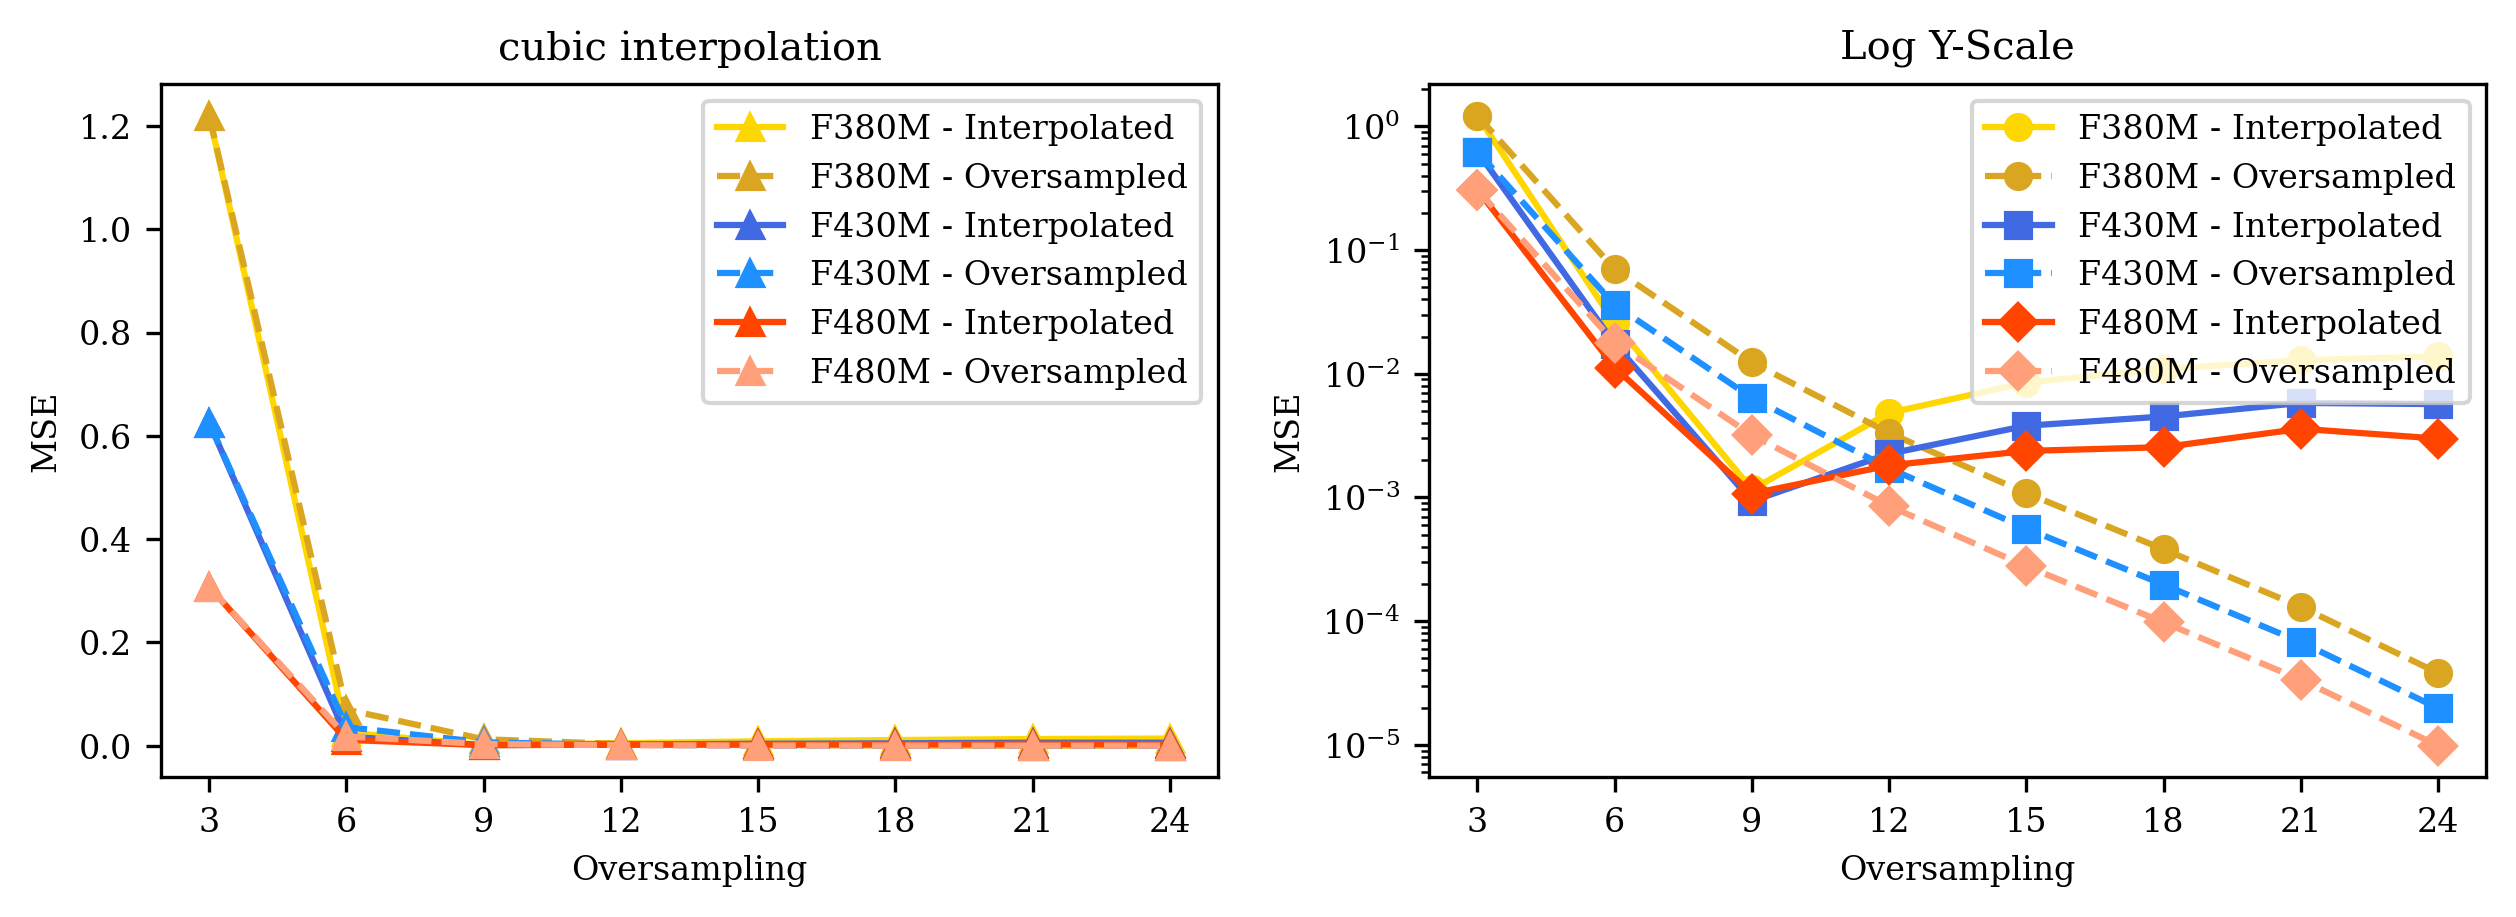

In [12]:
knots = dlu.pixel_coords(npixels=240, diameter=1.0)

FILTERS = [
    "F380M",
    "F430M",
    "F480M",
]
plot = False

interp_methods = [
    # "nearest",
    # "linear",
    "cubic",
    # "cubic2",
    # "catmull-rom",
    # "cardinal",
    # "monotonic",
    # "monotonic-0",
    # "akima",
]
mses = {}
mses_nointerp = {}
psfs = {}
for filter in FILTERS:
    # for filter in ["F430M"]:

    wavels, weights = model.filters[filter]
    psf = 1e6 * model.optics.propagate(wavels, weights=weights)
    psfs[filter] = psf

for method in interp_methods:
    for filter in FILTERS:
        # for filter in ["F430M"]:

        osamps = []
        mses_filt = []
        mses_nointerp_filt = []

        for i in range(1, 9):

            osamps.append(3 * i)

            # INTERPOLATION ROUTINE
            sample_coords = dlu.pixel_coords(npixels=240 * i, diameter=1.0)
            scaled_psf = amigo.misc.interp(
                psfs[filter], knots, sample_coords, method=method
            )
            ds_psf = dlu.downsample(scaled_psf, i)
            mses_filt.append(np.mean((god_psfs[filter] - ds_psf) ** 2))

            # OPTICS OVERSAMPLE ROUTINE
            osamp_model = model.set("oversample", 3 * i)
            wavels, weights = model.filters[filter]
            osamp_psf = 1e6 * osamp_model.optics.propagate(wavels, weights=weights)
            osamp_psf = i * i * dlu.downsample(osamp_psf, i)

            mses_nointerp_filt.append(np.mean((god_psfs[filter] - osamp_psf) ** 2))

            if plot:
                print(psfs[filter].shape, scaled_psf.shape, ds_psf.shape)

                plt.figure(figsize=(12, 3))
                plt.subplot(1, 3, 1)
                plt.title("interpolation")
                plt.imshow(god_psfs[filter])
                plt.colorbar()
                plt.subplot(1, 3, 2)
                plt.imshow(ds_psf)
                plt.colorbar()

                residuals = god_psfs[filter] - ds_psf
                plt.subplot(1, 3, 3)
                plt.imshow(residuals, seismic, norm=mpl.colors.CenteredNorm())
                plt.colorbar()
                plt.show()

                plt.figure(figsize=(12, 3))
                plt.subplot(1, 3, 1)
                plt.title("oversampling")
                plt.imshow(god_psfs[filter])
                plt.colorbar()
                plt.subplot(1, 3, 2)
                plt.imshow(osamp_psf)
                plt.colorbar()

                residuals = god_psfs[filter] - osamp_psf
                plt.subplot(1, 3, 3)
                plt.imshow(residuals, seismic, norm=mpl.colors.CenteredNorm())
                plt.colorbar()
                plt.show()

        mses[filter] = mses_filt
        mses_nointerp[filter] = mses_nointerp_filt

    plt.figure(figsize=(10, 3))

    plt.subplot(1, 2, 1)
    plt.title(f"{method} interpolation")
    for filter, c in zip(
        # ["F430M"],
        FILTERS,
        [
            ("gold", "goldenrod"),
            ("royalblue", "dodgerblue"),
            ("orangered", "lightsalmon"),
        ],
    ):
        plt.plot(
            osamps,
            mses[filter],
            c=c[0],
            label=f"{filter} - Interpolated",
            marker="^",
        )
        plt.plot(
            osamps,
            mses_nointerp[filter],
            c=c[1],
            label=f"{filter} - Oversampled",
            linestyle="--",
            marker="^",
        )
    plt.xlabel("Oversampling")
    plt.ylabel("MSE")
    plt.xticks(osamps)
    plt.legend()

    plt.subplot(1, 2, 2)
    for filter, c, m in zip(
        # ["F430M"],
        FILTERS,
        [
            ("gold", "goldenrod"),
            ("royalblue", "dodgerblue"),
            ("orangered", "lightsalmon"),
        ],
        ["o", "s", "D"],
    ):

        plt.plot(
            osamps,
            mses[filter],
            c=c[0],
            label=f"{filter} - Interpolated",
            marker=m,
        )
        plt.plot(
            osamps,
            mses_nointerp[filter],
            c=c[1],
            label=f"{filter} - Oversampled",
            marker=m,
            linestyle="--",
        )
    plt.xlabel("Oversampling")
    plt.ylabel("MSE")
    plt.yscale("log")
    plt.title("Log Y-Scale")
    plt.xticks(osamps)
    plt.legend()
    plt.show()

TypeError: unhashable type: 'dict'

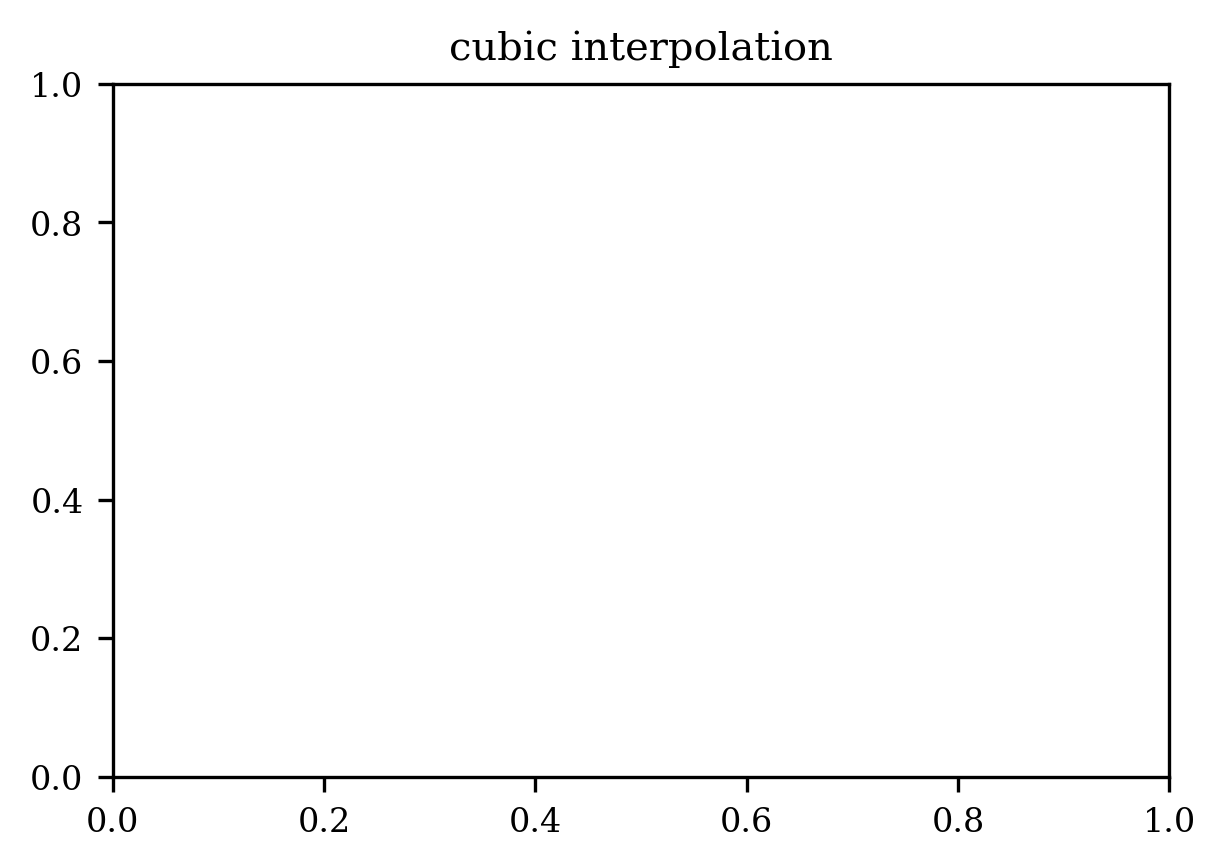

In [ ]:
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.title(f"{method} interpolation")
plt.plot(osamps, mses, c="goldenrod", label="Interpolated", marker="^")
plt.plot(osamps, mses_nointerp, c="royalblue", label="No Interpolation", marker="^")
plt.xlabel("Oversampling")
plt.ylabel("MSE")
plt.xticks(osamps)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(osamps, mses, c="goldenrod", label="Interpolated", marker="^")
plt.plot(osamps, mses_nointerp, c="royalblue", label="No Interpolation", marker="^")
plt.xlabel("Oversampling")
plt.ylabel("MSE")
plt.yscale("log")
plt.xticks(osamps)
plt.legend()
plt.show()